## 25.09.04: UNet segmentation model (1st trial run)

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

from tqdm import tqdm
from itertools import pairwise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2
from ultralytics import YOLO

from scripts.datasets.calibration import CalibrationDataset
from scripts.datasets.field_masking import MaskingCalibrationDataset
from SoccerNet.Downloader import SoccerNetDownloader

print(f'Torch CUDA availability: {torch.cuda.is_available()}')
print(f'Torch MPS availability: {torch.mps.is_available()}')

ModuleNotFoundError: No module named 'numpy'

In [2]:
masking_calibration_train_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/train', 
                                                                          mode='train', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_test_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/test', 
                                                                          mode='test', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
masking_calibration_valid_dataset = MaskingCalibrationDataset.from_folder('../data/calibration/valid', 
                                                                          mode='valid', transform=lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
print(f'Number of training samples: {len(masking_calibration_train_dataset)}')
print(f'Number of test samples: {len(masking_calibration_test_dataset)}')
print(f'Number of valid samples: {len(masking_calibration_valid_dataset)}')

Number of training samples: 12356
Number of test samples: 2719
Number of valid samples: 2796


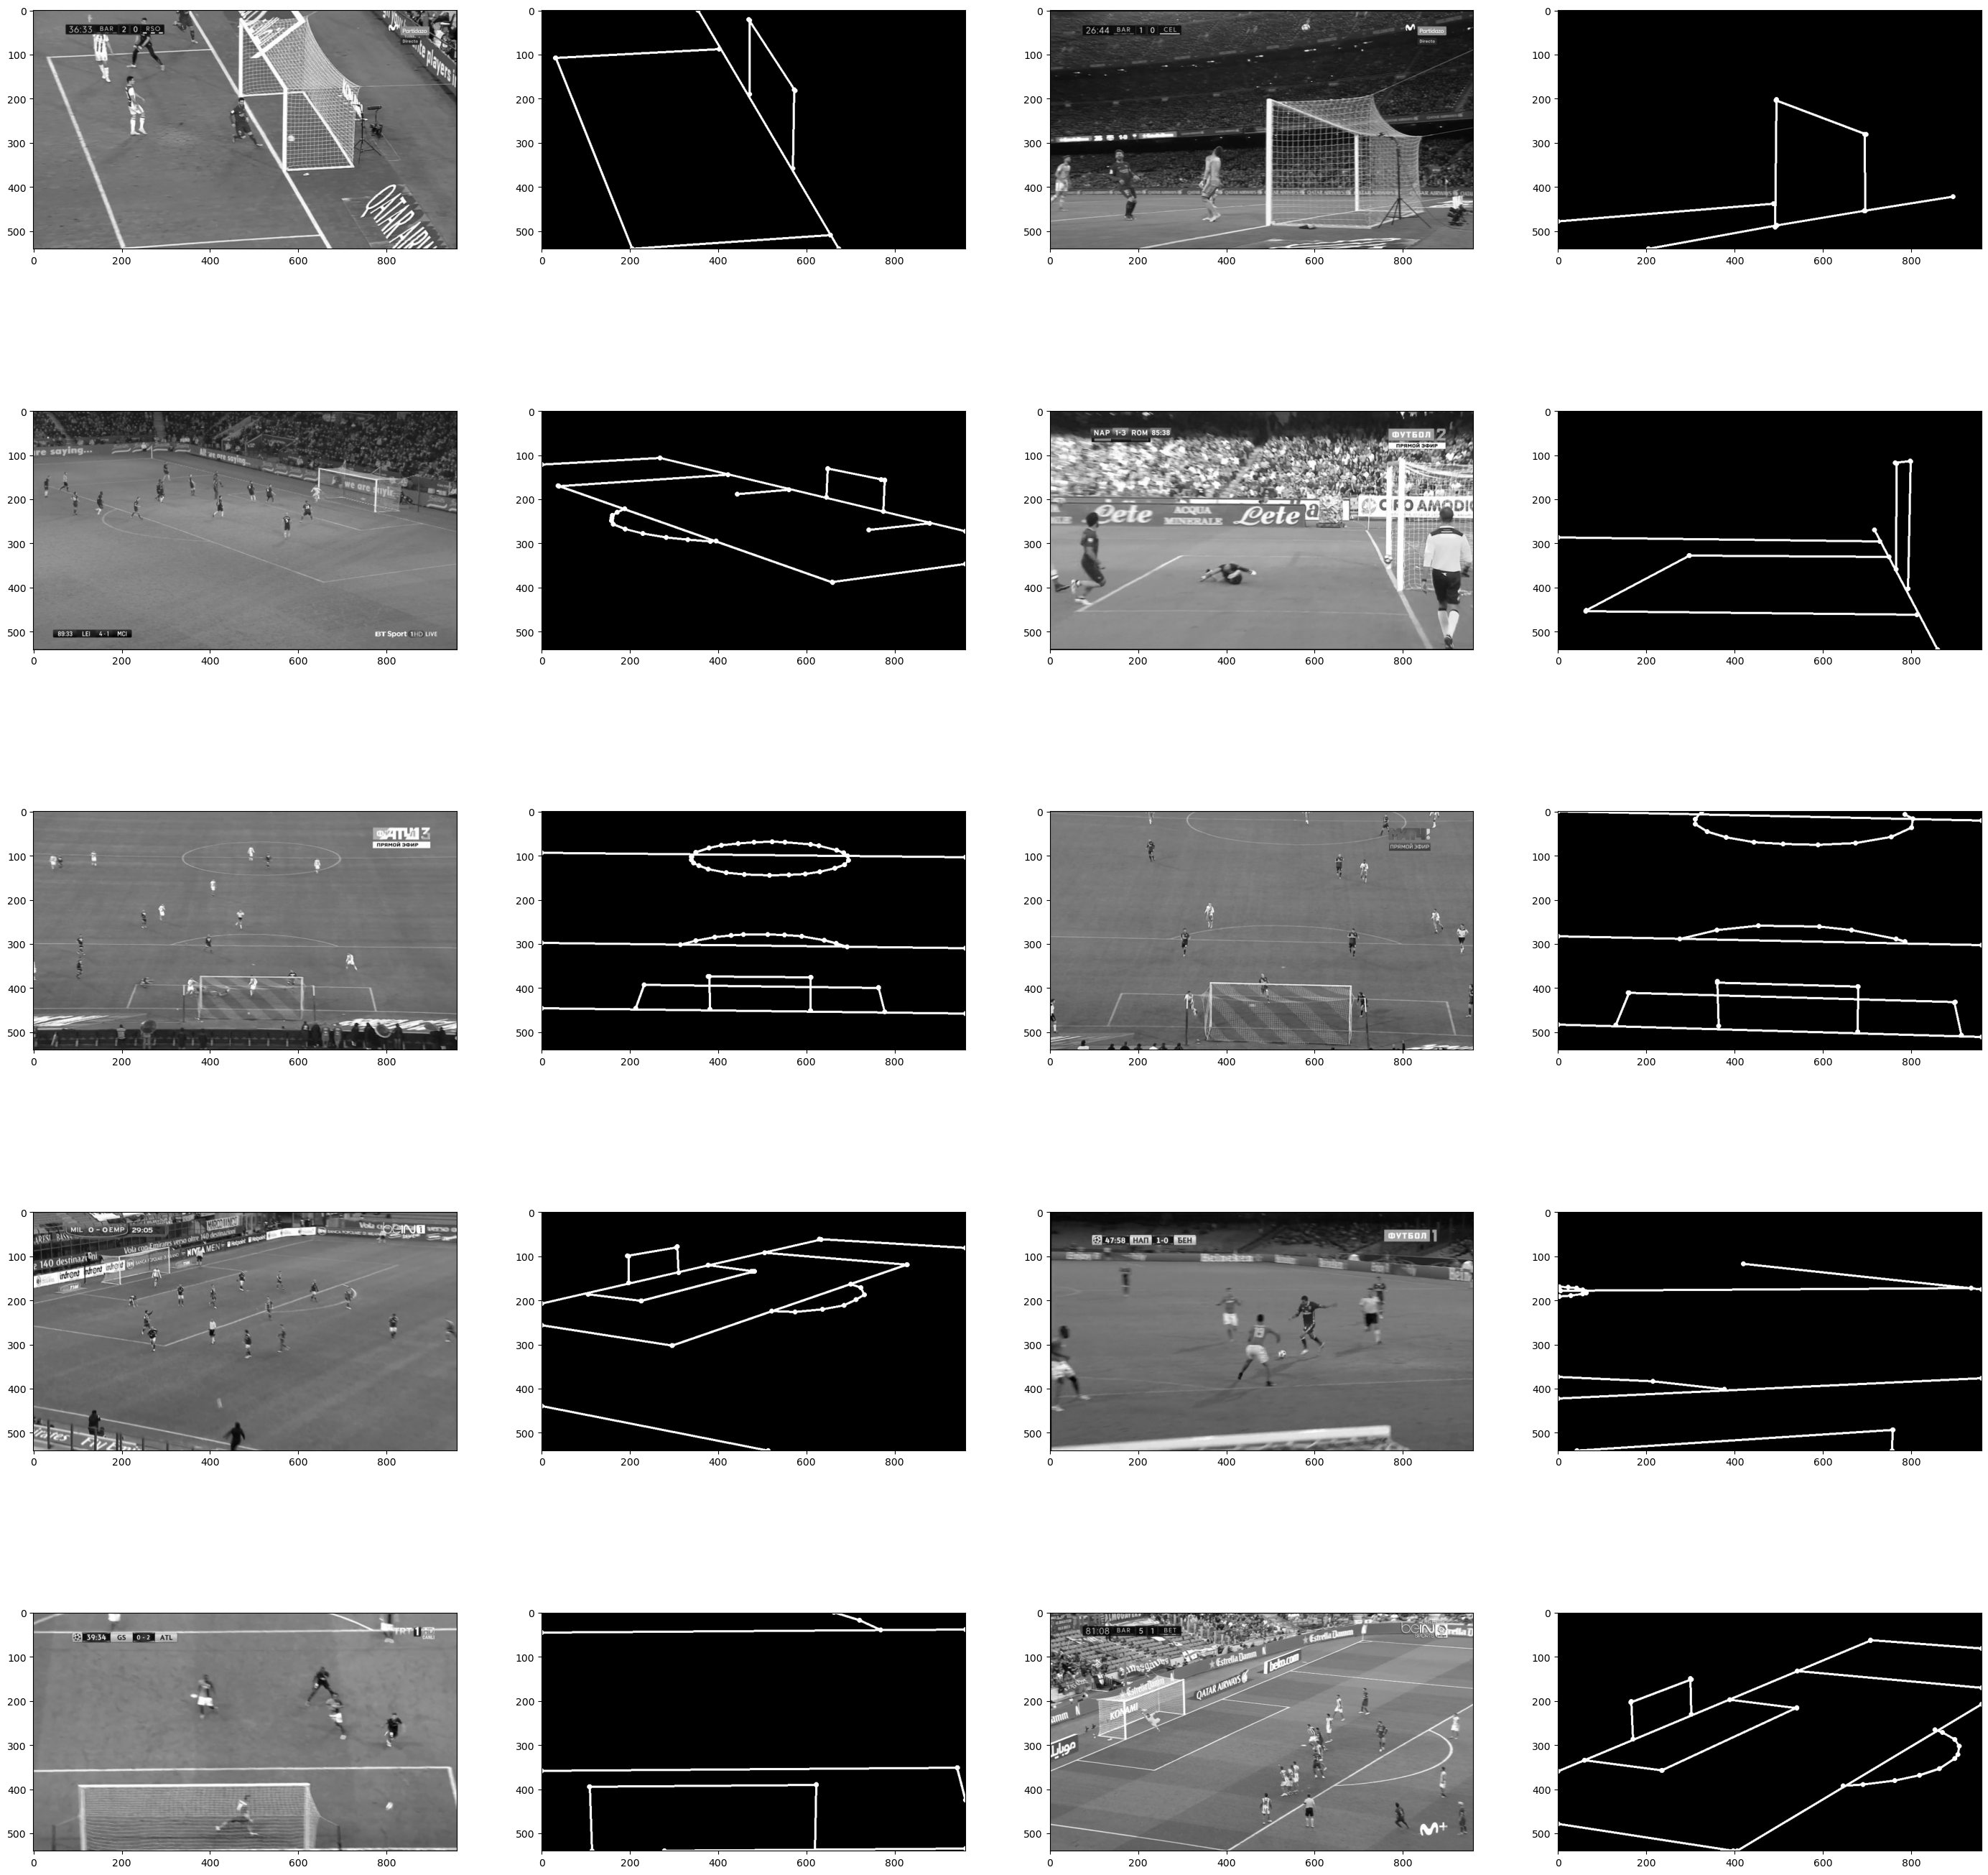

In [3]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(35, 35))

for idx in range(0, len(axes.flat), 2):
    img, mask = masking_calibration_train_dataset[idx]
    axes.flat[idx].imshow(img, cmap='gray')
    axes.flat[idx + 1].imshow(mask, cmap='gray')

plt.show()

## UNet

https://arxiv.org/abs/2504.14131

In [4]:
DEVICE = torch.device('mps')
torch.mps.empty_cache()

unet_model = torch.hub \
    .load('sm00thix/unet', 'unet', pretrained=False, in_channels=1, out_channels=1, pad=True, bilinear=True, normalization=None) \
    .to(DEVICE)

print(f'UNet model device: {next(unet_model.parameters()).device}')

Using cache found in /Users/sam/.cache/torch/hub/sm00thix_unet_main


UNet model device: mps:0


In [ ]:
# https://medium.com/@weidagang/learning-pytorch-the-basic-program-structure-ed5723118b67

n_epochs = 16    # number of epochs to run
batch_size = 8   # size of each batch
batches_per_epoch = 16

train_dataloader = DataLoader(masking_calibration_train_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(masking_calibration_test_dataset, batch_size=batch_size, shuffle=False)
loss_fn = nn.MSELoss().to(DEVICE)  # binary cross entropy
optimiser = optim.Adam(unet_model.parameters(), lr=0.001)

4it [00:53, 13.38s/it]
0it [00:00, ?it/s]/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_84852/2914869295.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
0it [00:05, ?it/s]



Epoch: 1, Test Loss: 0.7126



4it [00:54, 13.53s/it]
0it [00:05, ?it/s]



Epoch: 2, Test Loss: 1.1048



1it [00:22, 22.64s/it]


KeyboardInterrupt: 

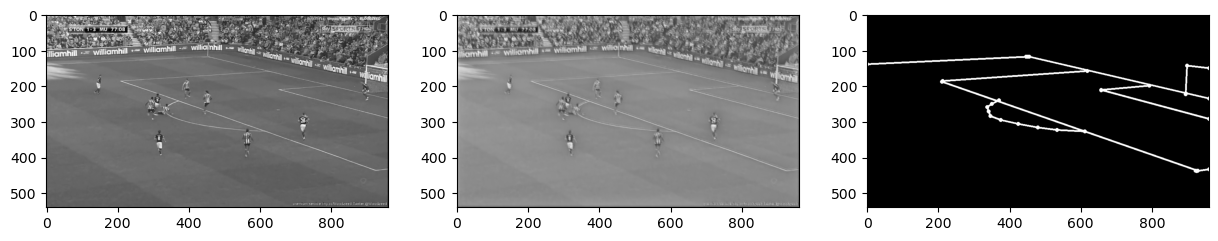

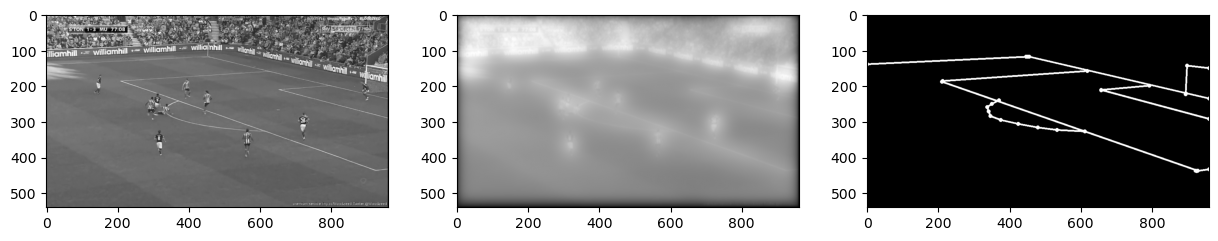

In [6]:
losses = []

for epoch in range(n_epochs):                                       
    unet_model.train()                                                  # Set the model to training mode
    for batch_idx, (img, mask) in tqdm(enumerate(train_dataloader)):    # Iterate over batches of data
        if batch_idx >= batches_per_epoch:
            break

        # img:  [(N) x 540 (H) x 960 (W)]
        # mask: [(N) x 540 (H) x 960 (W)]

        img = img.float().unsqueeze(1).to(DEVICE)
        mask = mask.float().unsqueeze(1).to(DEVICE)

        optimiser.zero_grad()                                           # Clear gradients from the previous iteration
        out_mask = unet_model(img)                                      # Forward pass through the model

        loss = loss_fn(out_mask, mask)                                  # Calculate the loss
        loss.backward()                                                 # Compute gradients (backpropagation)
        optimiser.step()                                                # Update model parameters

    unet_model.eval()                                                   # Set the model to evaluation mode 
    test_loss = 0
    with torch.no_grad():                                               # Disable gradient calculations for efficiency
        for batch_idx, (img, mask) in tqdm(enumerate(test_dataloader)): # Iterate over test data
            if batch_idx >= batches_per_epoch // 2:
                break

            img = img.float().unsqueeze(1).to(DEVICE)
            mask = mask.float().unsqueeze(1).to(DEVICE)
            out_mask = unet_model(img)  
            test_loss += loss_fn(out_mask, mask).item()                 # Accumulate test loss 

            if batch_idx == 0:
                fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
                def img_convert(img):
                    return img.permute((1, 2, 0)).cpu().numpy()

                axes.flat[0].imshow(img_convert(img[0]), cmap='gray')
                axes.flat[1].imshow(img_convert(out_mask[0]), cmap='gray')
                axes.flat[2].imshow(img_convert(mask[0]), cmap='gray')
                fig.show()
                break

    test_loss /= len(test_dataloader.dataset)                           # Calculate average test loss
    losses.append(test_loss)

    print('\nEpoch: {}, Test Loss: {:.4f}\n'.format(epoch + 1, test_loss))

torch.Size([4, 1, 540, 960])


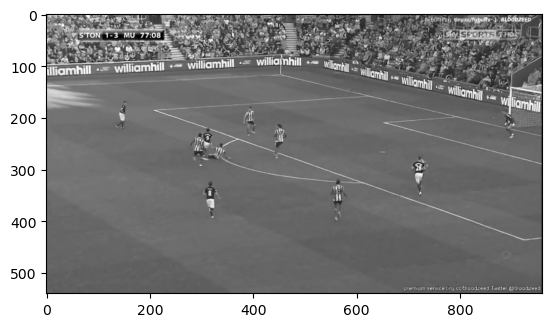

In [ ]:
print(img.shape)
plt.imshow(img[0][0].cpu(), cmap='gray')

In [ ]:
valid_dataloader = DataLoader(masking_calibration_valid_dataset, batch_size=batch_size, shuffle=False)
img, mask = next(iter(valid_dataloader))
img = img.float().unsqueeze(1)
mask = mask.float().unsqueeze(1)

unet_model.eval()
unet_model.to('cpu')
out_mask = unet_model(img)
print(f'img.shape = {img.shape}, out_mask.shape = {out_mask.shape}, mask.shape = {mask.shape}')

img.shape = torch.Size([8, 1, 540, 960]), out_mask.shape = torch.Size([8, 1, 540, 960]), mask.shape = torch.Size([8, 1, 540, 960])


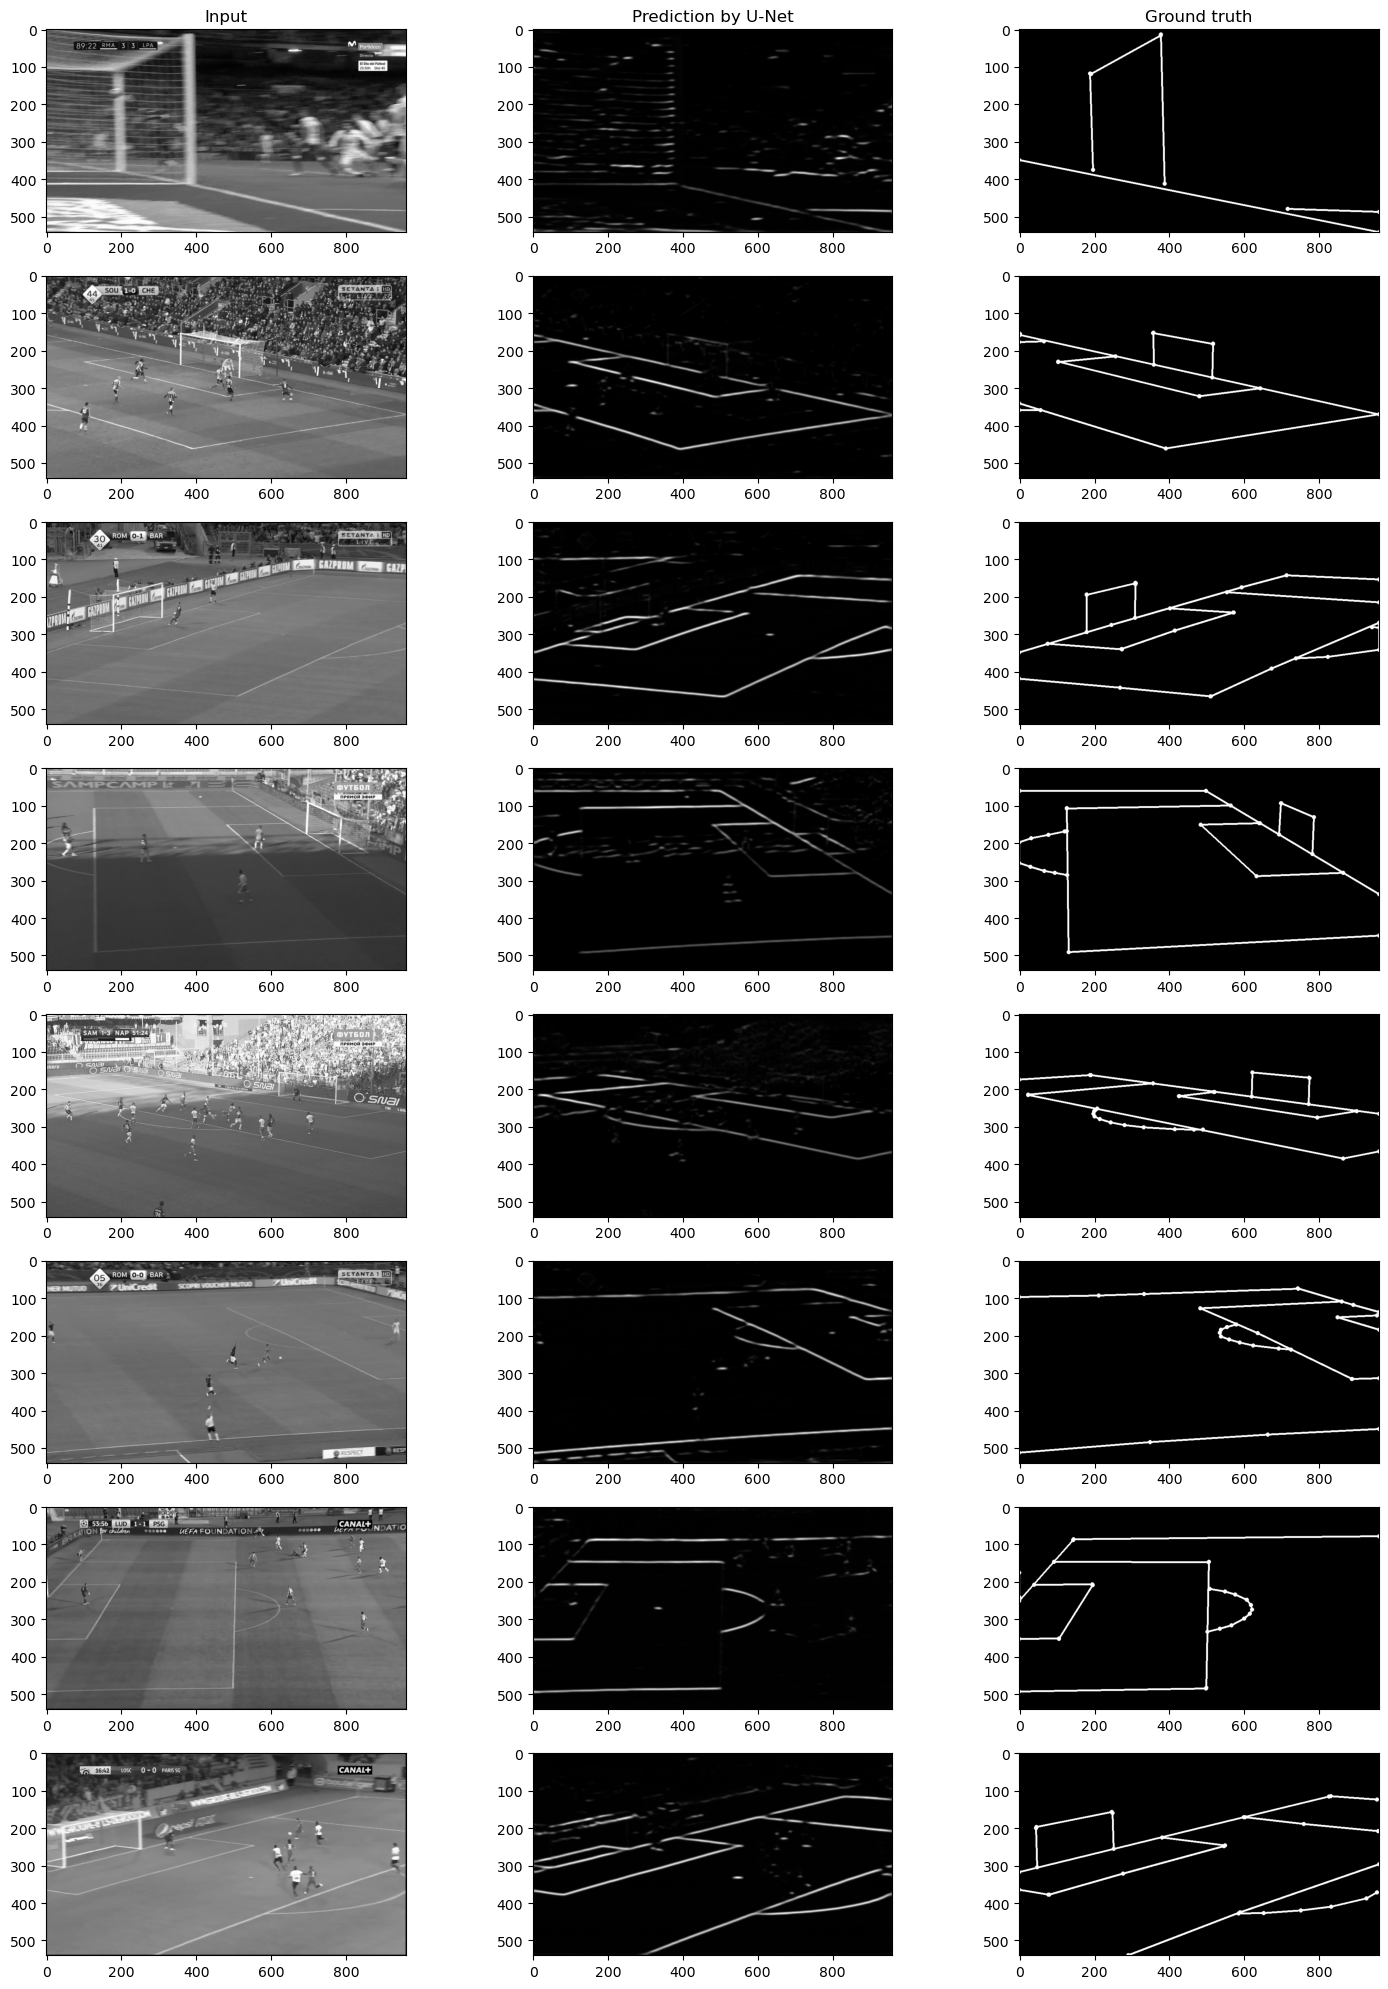

In [ ]:
fig, axes = plt.subplots(nrows=8, ncols=3, figsize=(15, 20))
def img_convert(img):
    return img.permute((1, 2, 0)).cpu().detach().numpy()

for idx in range(batch_size):
    axes[idx, 0].imshow(img_convert(img[idx]), cmap='gray')
    axes[idx, 1].imshow(img_convert(out_mask[idx]), cmap='gray')
    axes[idx, 2].imshow(img_convert(mask[idx]), cmap='gray')

axes[0, 0].set_title('Input')
axes[0, 1].set_title('Prediction by U-Net')
axes[0, 2].set_title('Ground truth')

fig.tight_layout()
plt.show()

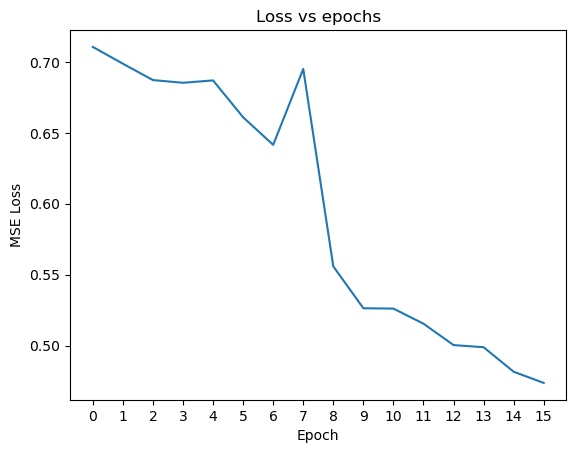

In [ ]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.xticks(range(len(losses)))
plt.title('Loss vs epochs')
plt.show()

In [ ]:
torch.save(unet_model.state_dict(), '../weights/experimental/250904-unet-model.pt')